# Quantum Fourier Transform

In [1]:
import math
from pandas import DataFrame as df
import numpy as np

import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.visualization import plot_bloch_vector, plot_histogram, plot_bloch_multivector, plot_state_city, plot_state_qsphere
from qiskit.visualization import array_to_latex
from qiskit_aer import AerSimulator
from qiskit_aer import Aer

from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import Initialize
from qiskit.quantum_info import random_statevector

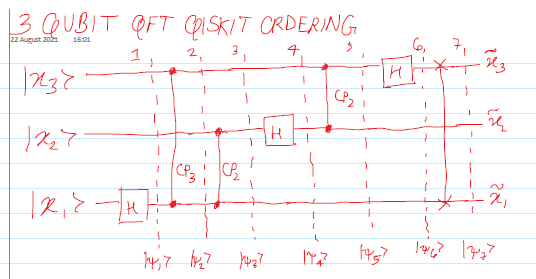

In [2]:
def qft_rotations(circuit, n):
    if n==0:
        return circuit
    n -= 1 # n = n-1, done since the qubits are indexed from 0..n-1 (e.i 2)
    circuit.h(n)
    for qubit in range(n): # loop iterates 0 then 1 thats it  
        circuit.cp(np.pi/2**(n-qubit), qubit, n) #controlled phase rotaiton (i.e circuit.cp(pi/4,0,2),then circuit.cp(pi/2,1,2)
    qft_rotations(circuit, n)

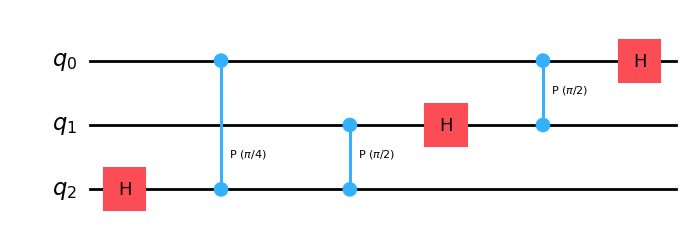

In [3]:
qc = QuantumCircuit(3)
k = 3
qft_rotations(qc,k)
qc.draw('mpl')

In [4]:
def swap_registers(circuit, n):
    for qubit in range(n//2): # // operator preforms floor devision (ex.3/2 is approximately 1.5. Round down to 1)
        circuit.swap(qubit, n-qubit-1) # ie. circuit.swap(0,2) and stops (if n=3 loop runs for 0 and thats it)
    return circuit #<-- OUTSIDE the loop

In [5]:
def qft(circuit,n):
    qft_rotations(circuit,n)
    swap_registers(circuit,n)
    return circuit

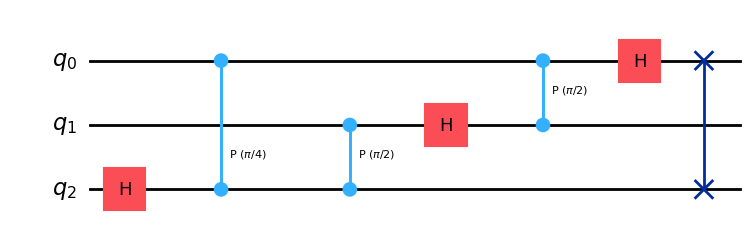

In [6]:
qc = QuantumCircuit(3)
qft(qc,3)
qc.draw('mpl')

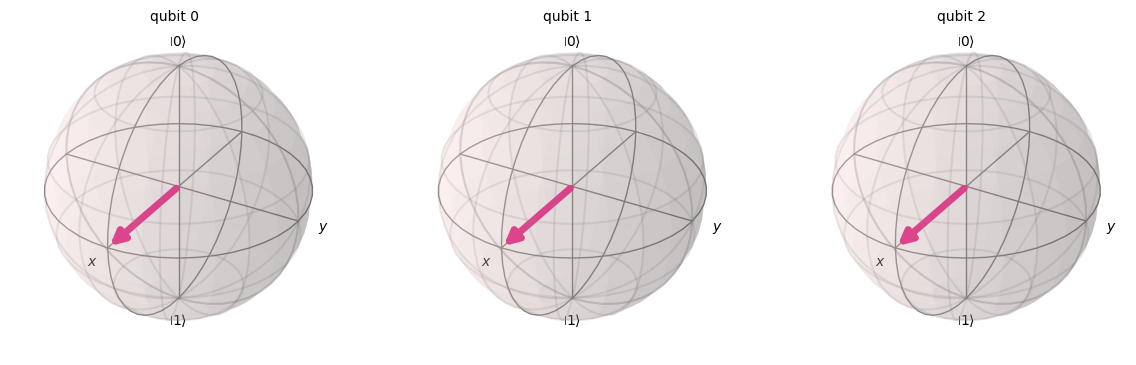

In [7]:
plot_bloch_multivector(qc) # this results in indeed the |+++> state (same as the example) 

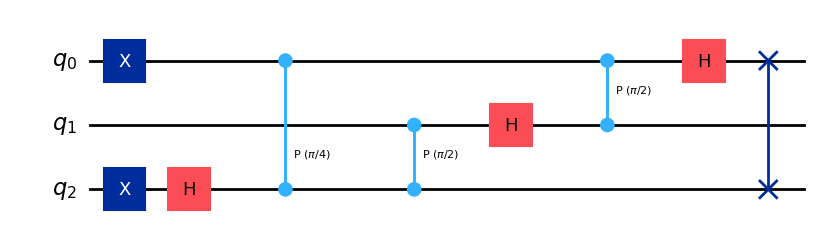

In [8]:
#|101> state
qc = QuantumCircuit(3)
qc.x(0)
qc.x(2)
qft(qc,3)
qc.draw('mpl')

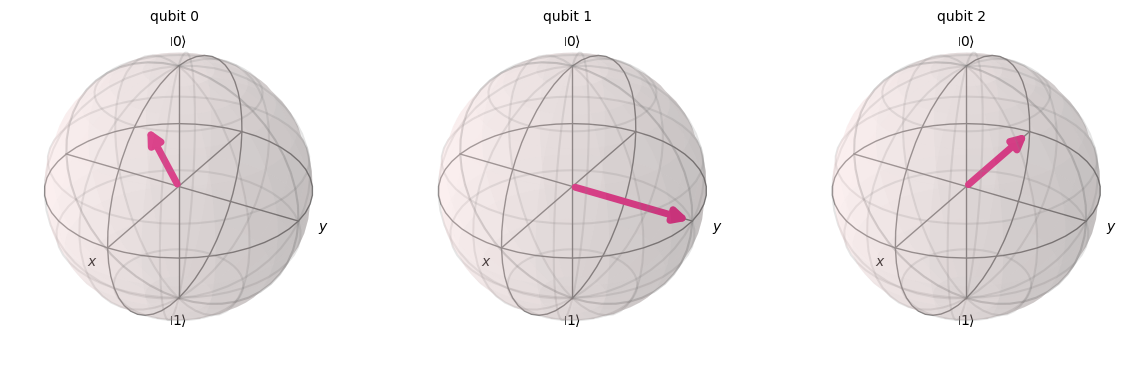

In [9]:
plot_bloch_multivector(qc)#  

# Inverse Quantum Fourier Transform (IQFT):

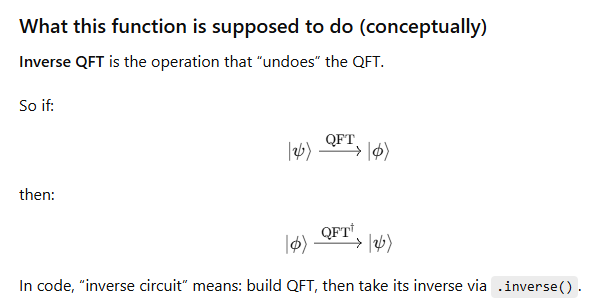

In [10]:
def inverse_qft(circuit,n):
    qft_circ = qft(QuantumCircuit(n),n) # we already defined qft, so qft_circ is literally a circuit object that contains the QFT gate sequence.
    invqft_circ = qft_circ.inverse()
    circuit.append(invqft_circ, circuit.qubits[:n]) #attaches inverse circuit onto your current circuit
    return circuit.decompose() #decompose() just expands the “black box” into basic gates
"""
decompose() tells Qiskit:
expand it into the underlying H, CP, SWAP gates (and maybe further into basis gates depending)
So you can actually see the inverse sequence.
"""

'\ndecompose() tells Qiskit:\nexpand it into the underlying H, CP, SWAP gates (and maybe further into basis gates depending)\nSo you can actually see the inverse sequence.\n'

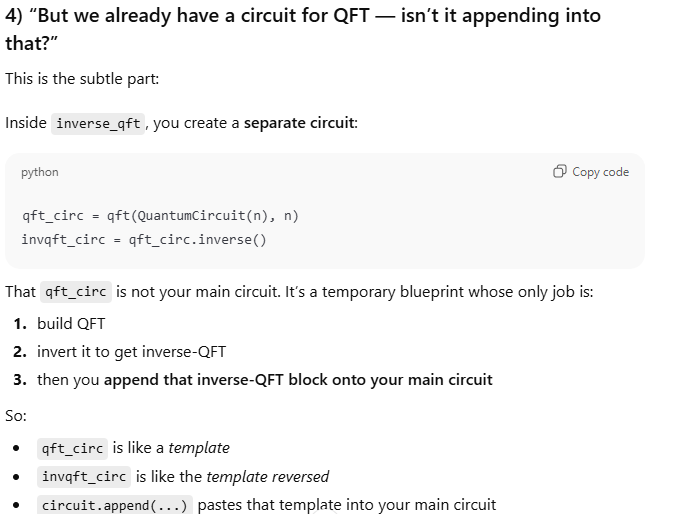

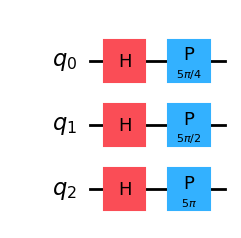

In [11]:
nqubits = 3 
number = 5 
qc = QuantumCircuit(nqubits)
for qubit in range(nqubits): # This part is NOT QFT-related its state preperation. 
    qc.h(qubit)
qc.p(number*np.pi/4,0)
qc.p(number*np.pi/2,1)
qc.p(number*np.pi,2)
qc.draw('mpl')

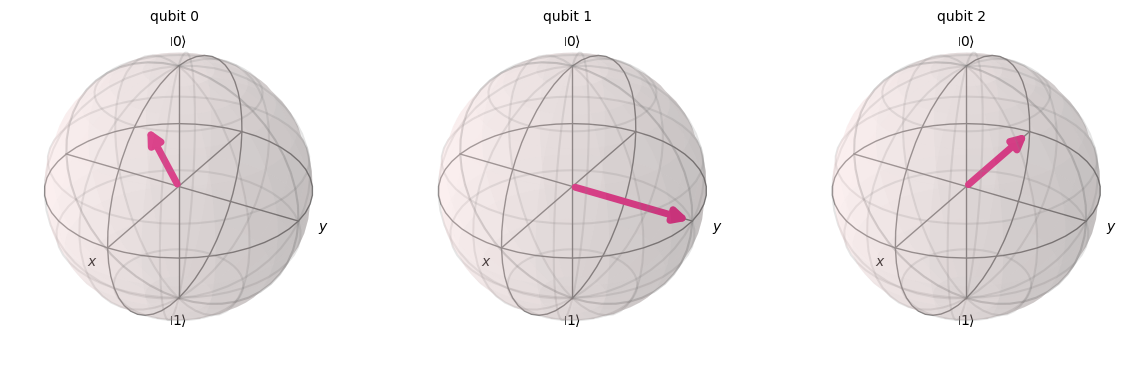

In [12]:
plot_bloch_multivector(qc)  

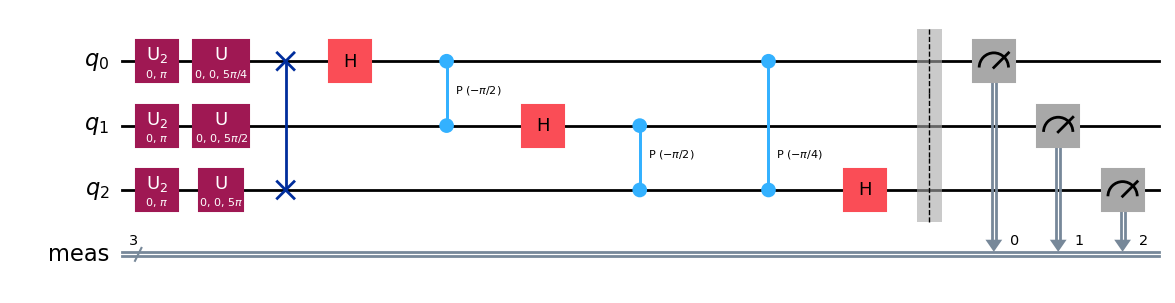

In [13]:
qc = inverse_qft(qc,nqubits)
qc.measure_all()
qc.draw("mpl")


Total Counts are: {'101': 1000}


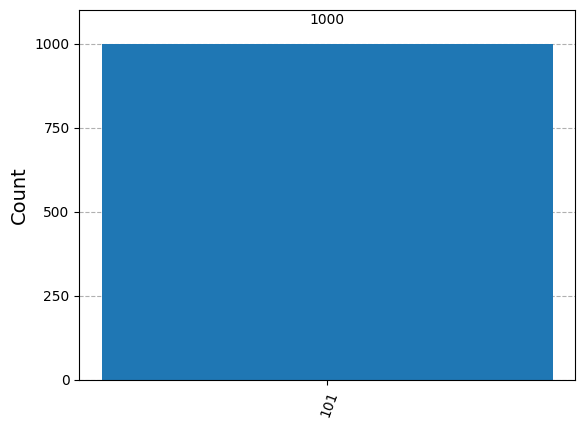

In [14]:
backend = Aer.get_backend('qasm_simulator') 

qct = transpile(qc, backend)
result = backend.run(qct, shots=1000).result()

counts = result.get_counts()
print("\nTotal Counts are:", counts)
plot_histogram(counts)

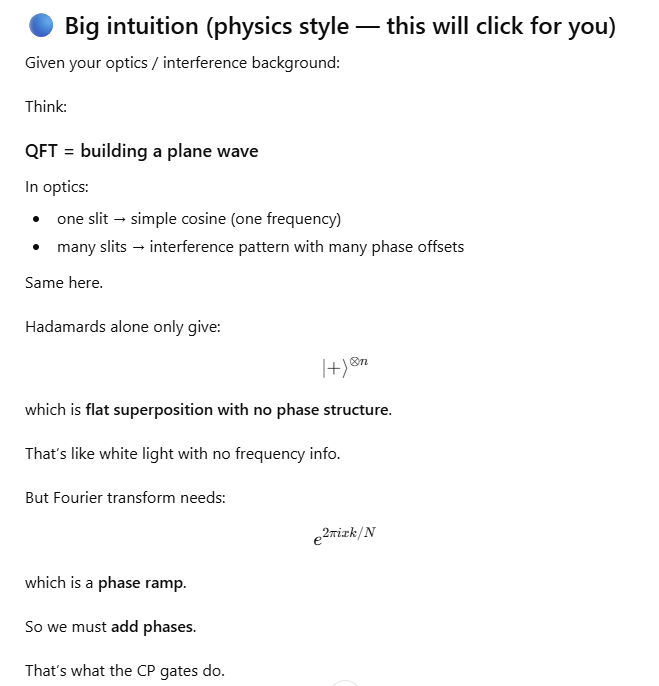

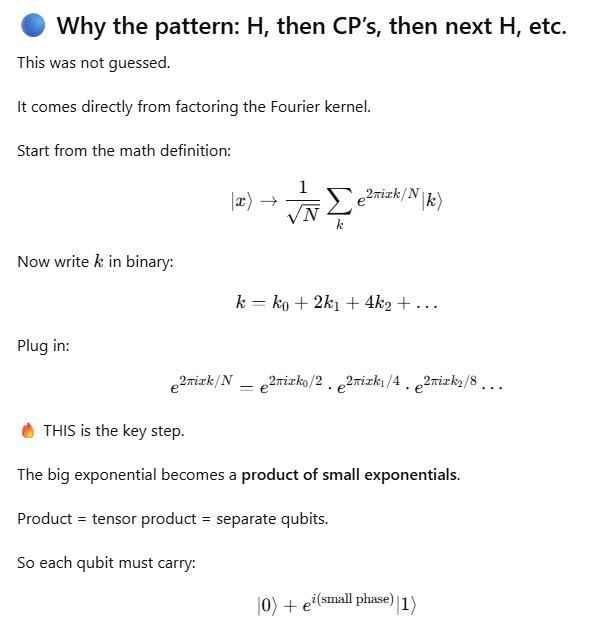

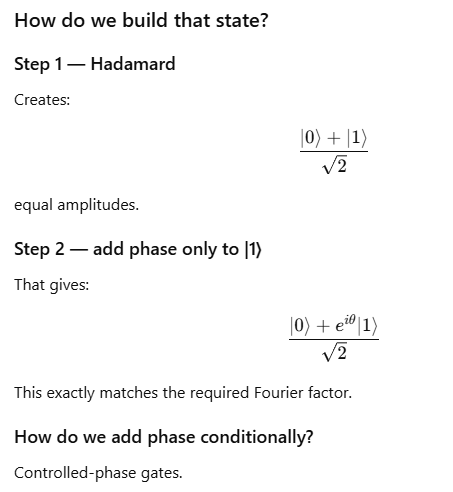

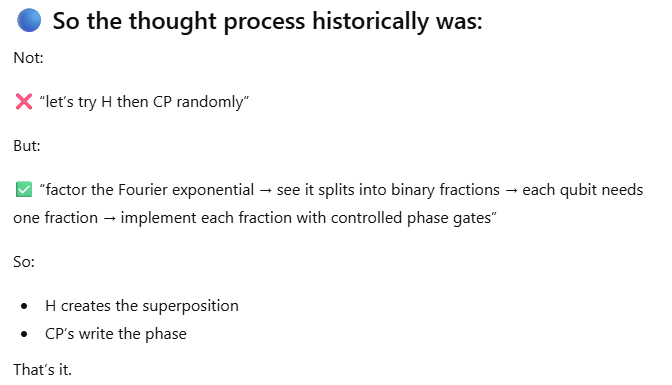